<a href="https://colab.research.google.com/github/thogaspar/econ3916-lab03-visualization/blob/main/Copy_of_lab_ch03_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Good, Bad, and Ugly — Honest vs. Misleading Visualizations
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 6 min Part 0 + 50 minutes

---

**Learning Objectives:**
- Recreate Anscombe's Quartet and compute summary statistics that hide the visual differences
- Calculate the Lie Factor for a truncated-axis chart and redesign it honestly
- Compare four charts of the same FRED wage data that tell four different stories
- Run a systematic EDA workflow on World Bank WDI data: structure, distributions, relationships, anomalies

**Dataset:** Anscombe's Quartet (seaborn), FRED wages, World Bank WDI

**How this lab works:** Parts 0-4 are GUIDED: run each cell as it is, then answer the questions. Part 5 is your README.

**Prerequisites:** Part 0 of this lab (below), plus matplotlib basics from Labs 1-2,
Chapter 3 reading (Anscombe, Lie Factor, Data-Ink Ratio)

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

---

> ### What you write, and what you run
>
> **Past its due date?** Keep this lab open as a worked example while you write
> Problem Set 1. It puts honest and misleading charts side by side and says what
> each one does to a reader.
>
> **You write:** the answers to the interpretation questions after Parts 1–4, in
> text cells; the three answers after the AI Expansion; and your README (Part 5),
> drafted with the README prompt and checked against your own numbers. There are
> no code blanks.
>
> **You run and read:** every code cell except one. They are working code to learn from. Read
> each one before you run it, and find the one line that makes the chart honest or
> misleading: a `set_ylim`, a `.loc["2015":]`, a `set_yscale`. The exception is
> the AI Expansion cell, which starts empty: you paste in the code the AI writes.
>
> **Charts to model Problem Set 1 on:** Step 10 (several lines, labelled axes with
> units, a legend, and a title that states the finding) and Step 5 (the honest
> redesign).
>
> **Code you write yourself:** none in this lab. Writing code from a blank cell is
> what Problem Set 1 grades; its ungraded warm-up, linked from the PS1 assignment,
> is the practice.

## Setup

<!-- idiom-note -->
> ### New idiom — loops over pairs, small functions, and `try` / `except`
>
> This lab's code uses four shapes you have not written yet. You will **read**
> them here, not write them; recognising them is enough.
>
> | Shape | Read it as | First seen |
> |---|---|---|
> | `lambda d: d["x"].corr(d["y"])` | a one-line function with no name: take `d`, hand back the correlation of its `x` and `y` | Step 1 |
> | `for ax, ds in zip(axes.flatten(), datasets):` | walk two lists side by side, one pair per step; `.flatten()` turns the 2 x 2 grid of panels into one list of four | Step 2 |
> | `def wage_panel(ax, data, title, note):` | name a block of code once, then run it with different inputs (Step 6's `load_fred` is the one from Lab 2) | Step 7 |
> > | `try: ... except ModuleNotFoundError: ...` | attempt something, and handle **one specific** failure rather than stopping | the save cell |
>
> On the last one: always catch the narrow exception you expect
> (`KeyError`, `ModuleNotFoundError`). A bare `except:` swallows real bugs and
> leaves you debugging blind.

In [18]:
# GUIDED — run as-is
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

### A word on seaborn, since this is the first time you have seen it

`seaborn` (imported as `sns`) is a thin layer on top of matplotlib. It does not
replace matplotlib — it calls it. You use it for two things in this lab:

- **`sns.load_dataset("anscombe")`** downloads one of about twenty small classic
  teaching datasets that seaborn hosts on GitHub, and hands it back as a DataFrame.
  It is a fixture, not your data: the name is fixed, the contents never change, and
  every textbook that uses Anscombe's Quartet is using these same 44 rows. It needs
  an internet connection, nothing else.
- **Statistical chart types** that would take a dozen matplotlib lines to build by
  hand. Step 11 uses two, `sns.boxplot` and `sns.heatmap`. Each draws on a
  matplotlib axes, so everything you learned about `ax.set_xlabel(...)` still applies.

One thing that is *not* seaborn: `plt.style.use("seaborn-v0_8-whitegrid")` in the
cell above. That is matplotlib wearing seaborn's colour scheme, and it works whether
or not seaborn is installed. The `v0_8` in the name is matplotlib recording which
version of seaborn's look it copied.

Everything in this lab is a DataFrame going into a matplotlib axes, exactly as in
Labs 0-2.

<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 6 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** how a matplotlib figure is actually built — `fig`, `ax`, and `savefig`.

This lab is about whether a chart tells the truth. Before judging one, you need
to know which line of code made which part of it.

`plt.subplots()` hands back **two** things: the **figure** (the sheet of paper)
and the **axes** (the plot drawn on it). You draw on `ax`, and you save `fig`.
Almost every chart in this course starts with that line.

The two labels and the title are not decoration: an unlabelled axis is the most
common way an honest chart still misleads. And the y-axis starting at zero is a
**choice**. Part 2 is about what that choice does to a reader; setting it
yourself is how you take responsibility for it.

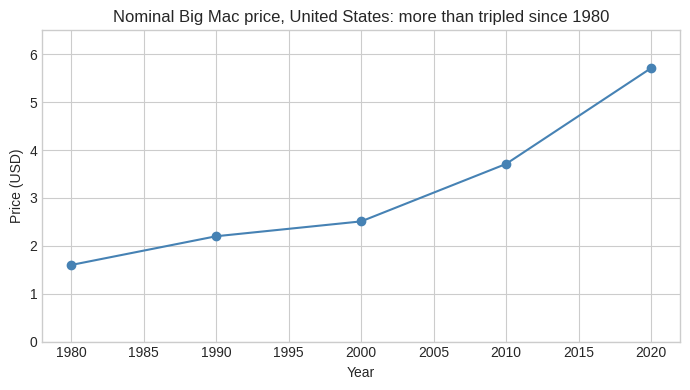

Saved to figures/ch03_step0.png
fig is a Figure; ax is an Axes


In [19]:
# GUIDED — run as-is
# Step 0: how a matplotlib figure is actually built
from pathlib import Path

# savefig will not create a folder, so make figures/ first
Path("figures").mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))

years  = [1980, 1990, 2000, 2010, 2020]
prices = [1.60, 2.20, 2.51, 3.71, 5.71]
ax.plot(years, prices, marker="o", color="steelblue")

ax.set_xlabel("Year")
ax.set_ylabel("Price (USD)")
ax.set_title("Nominal Big Mac price, United States: more than tripled since 1980")
ax.set_ylim(0, 6.5)

plt.tight_layout()
plt.savefig("figures/ch03_step0.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to figures/ch03_step0.png")
# type(x).__name__ is the name of x's type
print(f"fig is a {type(fig).__name__}; ax is an {type(ax).__name__}")

## Part 1: Anscombe's Quartet — When Statistics Lie (GUIDED — 10 min)

In 1973, statistician Francis Anscombe constructed four datasets that share **identical** summary statistics but look completely different when plotted. This is the single most important lesson in data visualization: *never trust summary statistics without plotting the data.*

In [20]:
# GUIDED — run as-is
# Step 1: load Anscombe's Quartet and compute its summary statistics

anscombe = sns.load_dataset("anscombe")
print(f"Shape: {anscombe.shape}")
print(f"Datasets: {list(anscombe['dataset'].unique())}\n")

# For each dataset d, the correlation between its x and y
correlations = anscombe.groupby("dataset")[["x", "y"]].apply(
    lambda d: d["x"].corr(d["y"])
).round(3)

summary = anscombe.groupby("dataset").agg(
    # each new column = (column to summarise, calculation)
    x_mean=("x", "mean"),
    y_mean=("y", "mean"),
    x_var=("x", "var"),
    y_var=("y", "var"),
).round(2)
summary["correlation"] = correlations

print(summary.to_string())

Shape: (44, 3)
Datasets: ['I', 'II', 'III', 'IV']

         x_mean  y_mean  x_var  y_var  correlation
dataset                                           
I           9.0     7.5   11.0   4.13        0.816
II          9.0     7.5   11.0   4.13        0.816
III         9.0     7.5   11.0   4.12        0.816
IV          9.0     7.5   11.0   4.12        0.817


**Expected output:** 44 rows, four datasets of eleven points each. Every column
agrees to two decimals: mean of x 9.0, mean of y 7.5, variance of x 11.0,
variance of y 4.12 or 4.13, correlation 0.816 or 0.817. Anscombe also built the
four to share one least-squares line, y = 3.0 + 0.5x, which Step 2 draws on each
panel. Judged by these numbers alone, the four datasets are interchangeable.
Step 2 shows they are not.

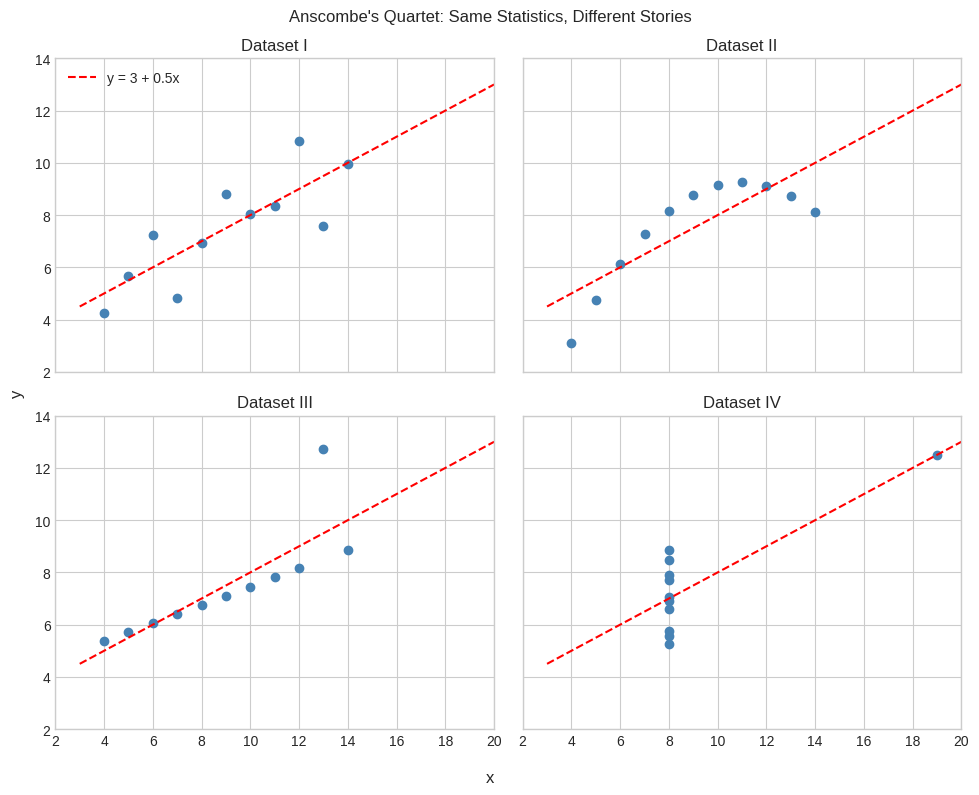

In [21]:
# GUIDED — run as-is
# Step 2: plot all four datasets, each with the shared line y = 3 + 0.5x

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

datasets = anscombe["dataset"].unique()
x_line = np.linspace(3, 20, 100)       # 100 evenly spaced x values, to draw the line
y_line = 3.0 + 0.5 * x_line

# axes is a 2 x 2 grid; .flatten() lays it out as one list of four
for ax, ds in zip(axes.flatten(), datasets):
    subset = anscombe[anscombe["dataset"] == ds]
    ax.scatter(subset["x"], subset["y"], color="steelblue")
    ax.plot(x_line, y_line, color="red", linestyle="--", label="y = 3 + 0.5x")
    ax.set_title(f"Dataset {ds}")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

axes[0, 0].legend()
fig.supxlabel("x")
fig.supylabel("y")
fig.suptitle("Anscombe's Quartet: Same Statistics, Different Stories")
plt.tight_layout()
plt.show()

### Interpretation Questions

**Q1:** Which dataset would make OLS regression most misleading? Why?

**Q2:** Dataset III has one outlier that pulls the regression line away from the otherwise perfect linear pattern. How would removing that single point change the correlation?

**Q3:** What is the lesson for your own data analysis workflow? When in the analysis pipeline should visualization happen?

*Your answers here:*

1. I believe the 4th dataset would be most missleading, as all x values are identical apart from one distinct outlier, this allows us to create a regression, but the correlation found relies on that singular outlier.
2. The correlation would be 0, or undefined, as removing the singular outlier causes all X values to be identical amongst variations in Y.
3. Visualization should be happening throughout the data analysis workflow, however the key lesson here is it's use early (before any actual analysis), during EDA so that you understand the shape, anomalies, patterns etc.. before coming to any logical conclusions.

## Part 2: Lie Factor and Honest Redesign (GUIDED — 10 min)

Edward Tufte's **Lie Factor** quantifies how much a chart exaggerates or understates the data:

$$\text{Lie Factor} = \frac{\text{Size of effect shown in the graphic}}{\text{Size of effect in the data}}$$

A Lie Factor of 1.0 means the chart is perfectly honest. Values far from 1.0 indicate distortion.

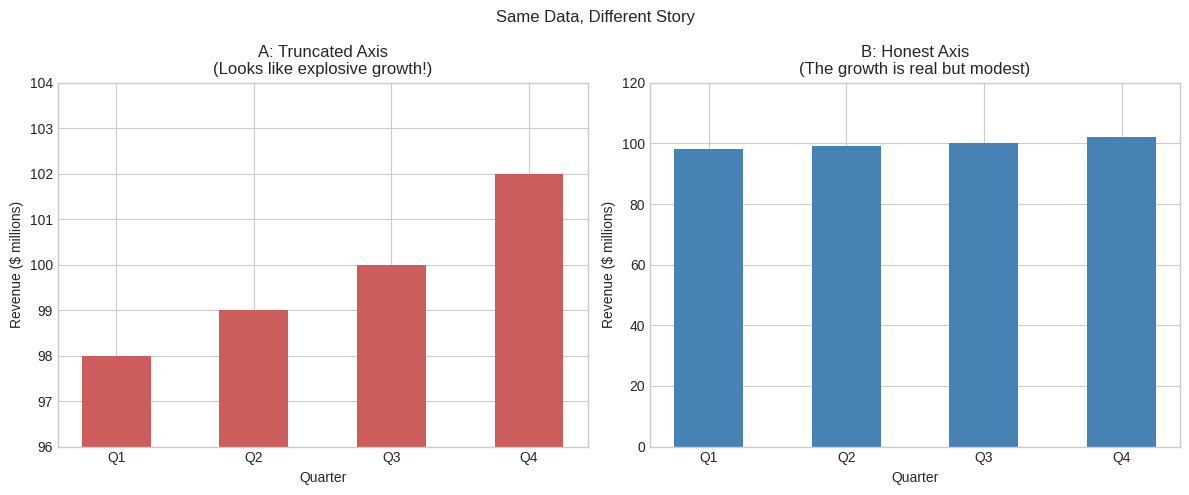

In [22]:
# GUIDED — run as-is
# Step 3: truncated vs. honest bar chart, side by side
# A company wants to impress investors with a "growth" chart

quarters = ["Q1", "Q2", "Q3", "Q4"]
revenue = [98, 99, 100, 102]         # millions of dollars
y_floor = 96                         # where the truncated axis starts

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(quarters, revenue, color="indianred", width=0.5)
axes[0].set_ylim(y_floor, 104)
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Revenue ($ millions)")
axes[0].set_title("A: Truncated Axis\n(Looks like explosive growth!)")

axes[1].bar(quarters, revenue, color="steelblue", width=0.5)
axes[1].set_ylim(0, 120)
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Revenue ($ millions)")
axes[1].set_title("B: Honest Axis\n(The growth is real but modest)")

fig.suptitle("Same Data, Different Story")
plt.tight_layout()
plt.show()

In [23]:
# GUIDED — run as-is
# Step 4: the Lie Factor, step by step

first, last = revenue[0], revenue[-1]      # [0] is the first item, [-1] the last

# The effect in the data: the percentage change from Q1 to Q4
data_effect = (last - first) / first

# The effect on screen: on the truncated chart a bar shows only the part above the floor
first_bar = first - y_floor
last_bar = last - y_floor
visual_effect = (last_bar - first_bar) / first_bar

lie_factor = visual_effect / data_effect

# :.4f prints four decimals, :.0f none
print(f"Data effect (actual change): ({last} - {first}) / {first} = {data_effect:.4f} = {data_effect*100:.1f}%")
print(f"Visual effect (perceived change): ({last_bar} - {first_bar}) / {first_bar} = {visual_effect:.4f} = {visual_effect*100:.0f}%")
print(f"\nLie Factor = {visual_effect:.2f} / {data_effect:.4f} = {lie_factor:.1f}")

Data effect (actual change): (102 - 98) / 98 = 0.0408 = 4.1%
Visual effect (perceived change): (6 - 2) / 2 = 2.0000 = 200%

Lie Factor = 2.00 / 0.0408 = 49.0


**Expected output:** a Lie Factor of 49.0. Revenue rose 4.1%, but on the
truncated chart the Q4 bar is three times the height of the Q1 bar, a 200%
jump. The chart makes the change look 49 times larger than it is.

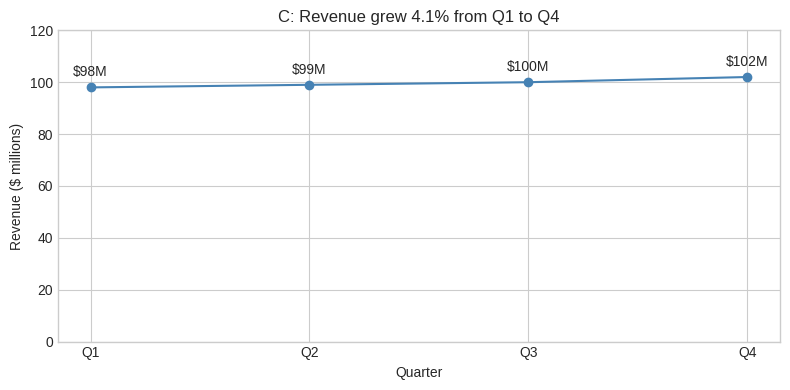

In [24]:
# GUIDED — run as-is
# Step 5: the honest redesign, a dot plot from $0 with each value labelled

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(quarters, revenue, marker="o", color="steelblue")

# Write each quarter's value 8 points above its dot
for q, r in zip(quarters, revenue):
    ax.annotate(f"${r}M", (q, r), textcoords="offset points", xytext=(0, 8), ha="center")

ax.set_ylim(0, 120)
ax.set_xlabel("Quarter")
ax.set_ylabel("Revenue ($ millions)")
ax.set_title(f"C: Revenue grew {data_effect*100:.1f}% from Q1 to Q4")

plt.tight_layout()
plt.show()

The dot plot keeps the honest scale and still makes the change visible: the
labels give the exact values, and the title states the finding in words. There
is no need to cut the axis to tell the story.

### Interpretation Questions

**Q1:** A colleague shows you a chart with Lie Factor = 12. What does that mean in plain English?

**Q2:** When is starting the y-axis at a non-zero value acceptable? Give a specific example from economics.

*Your answers here:*

1. A lie factor of 12 indicates that the visualization displays the effect at 12x magnitude compared to the actual difference in data.
2. This depends on the bounds of your data itself. One example would be the UMSCENT data series, a score of "0" for consumer sentiment likely wouldn't make any real-life sense, thus the graph maintains a lower bound of ~40.

## Part 3: Four Versions of One Dataset (GUIDED — 15 min)

Now we load real (deflated) wage data and build four panels that each tell a different story from the **same underlying numbers.** This is the core ethics lesson: visualization is a rhetorical choice.

The data come from FRED, with no API key needed: nominal average hourly earnings
of production workers (`AHETPI`, monthly since 1964) and the consumer price index
(`CPIAUCSL`). Chapter 2's rule applies: a wage in 1964 dollars and a wage in 2025
dollars are not the same unit, so Step 6 converts every month to 2020 dollars
before anything is plotted. It loads both series with the same `load_fred` you used in Lab 2.

In [25]:
# GUIDED — run as-is
# Step 6: load FRED earnings and the CPI, and convert the wage to 2020 dollars

def load_fred(series_id, start="1947-01-01"):
    """Return one FRED series, from `start` to the latest month, as a Series indexed by date."""
    # id picks the series; cosd is the first date to download
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
    frame = pd.read_csv(url)

    # Name the two columns ourselves: FRED has renamed its header before
    frame.columns = ["date", series_id]
    frame["date"] = pd.to_datetime(frame["date"])

    # errors="coerce" turns a value that is not a number (a blank month) into NaN
    frame[series_id] = pd.to_numeric(frame[series_id], errors="coerce")

    # Dates become the index; dropna() removes months with no value, so the dates can have gaps
    return frame.set_index("date")[series_id].dropna()


# A dictionary of Series becomes a DataFrame with one column per key, lined up by date;
# dropna() then keeps only the months where both series have a value
wages = pd.DataFrame({
    "AHETPI": load_fred("AHETPI", "1964-01-01"),        # average hourly earnings, production workers
    "CPIAUCSL": load_fred("CPIAUCSL", "1964-01-01"),    # consumer price index
}).dropna()

base = wages.loc["2020", "CPIAUCSL"].mean()     # "2020" picks every month of 2020
wages["wage"] = wages["AHETPI"] * base / wages["CPIAUCSL"]

# Three points on the real series, for Panel C below
avg_1973 = wages.loc["1973", "wage"].mean()
trough = wages["wage"].min()
trough_date = wages["wage"].idxmin()            # the date of the lowest value
avg_2015 = wages.loc["2015", "wage"].mean()

# .iloc[0] is the first row, .iloc[-1] the last
print(f"Loaded FRED data: {len(wages)} observations")
print(f"Date range: {wages.index.min().date()} to {wages.index.max().date()}")
print(f"Nominal:      ${wages['AHETPI'].iloc[0]:.2f}  ->  ${wages['AHETPI'].iloc[-1]:.2f}")
print(f"Real (2020$): ${wages['wage'].iloc[0]:.2f}  ->  ${wages['wage'].iloc[-1]:.2f}")
print(f"\nReal, 1973 average: ${avg_1973:.2f}")
print(f"Real, lowest month: ${trough:.2f} ({trough_date.date()})")
print(f"Real, 2015 average: ${avg_2015:.2f}")

Loaded FRED data: 751 observations
Date range: 1964-01-01 to 2026-08-01
Nominal:      $2.50  ->  $32.53
Real (2020$): $20.92  ->  $25.20

Real, 1973 average: $24.12
Real, lowest month: $19.71 (1995-04-01)
Real, 2015 average: $22.96


**Expected output:** 751 months, January 1964 to August 2026 (752 calendar
months; one month has no CPI value, so `dropna()` drops it). Nominal earnings
rose from \$2.50 to \$32.53, thirteen times over. Real earnings rose about twenty
percent in sixty years (\$20.92 to \$25.20), and fell for most of the middle
forty: \$24.12 on average in 1973, \$19.71 at the low in April 1995, and still only
\$22.96 in 2015. Every panel below plots the **real** series, the deflated one.
(FRED revises and adds a month at a time, so a later run can differ slightly.)

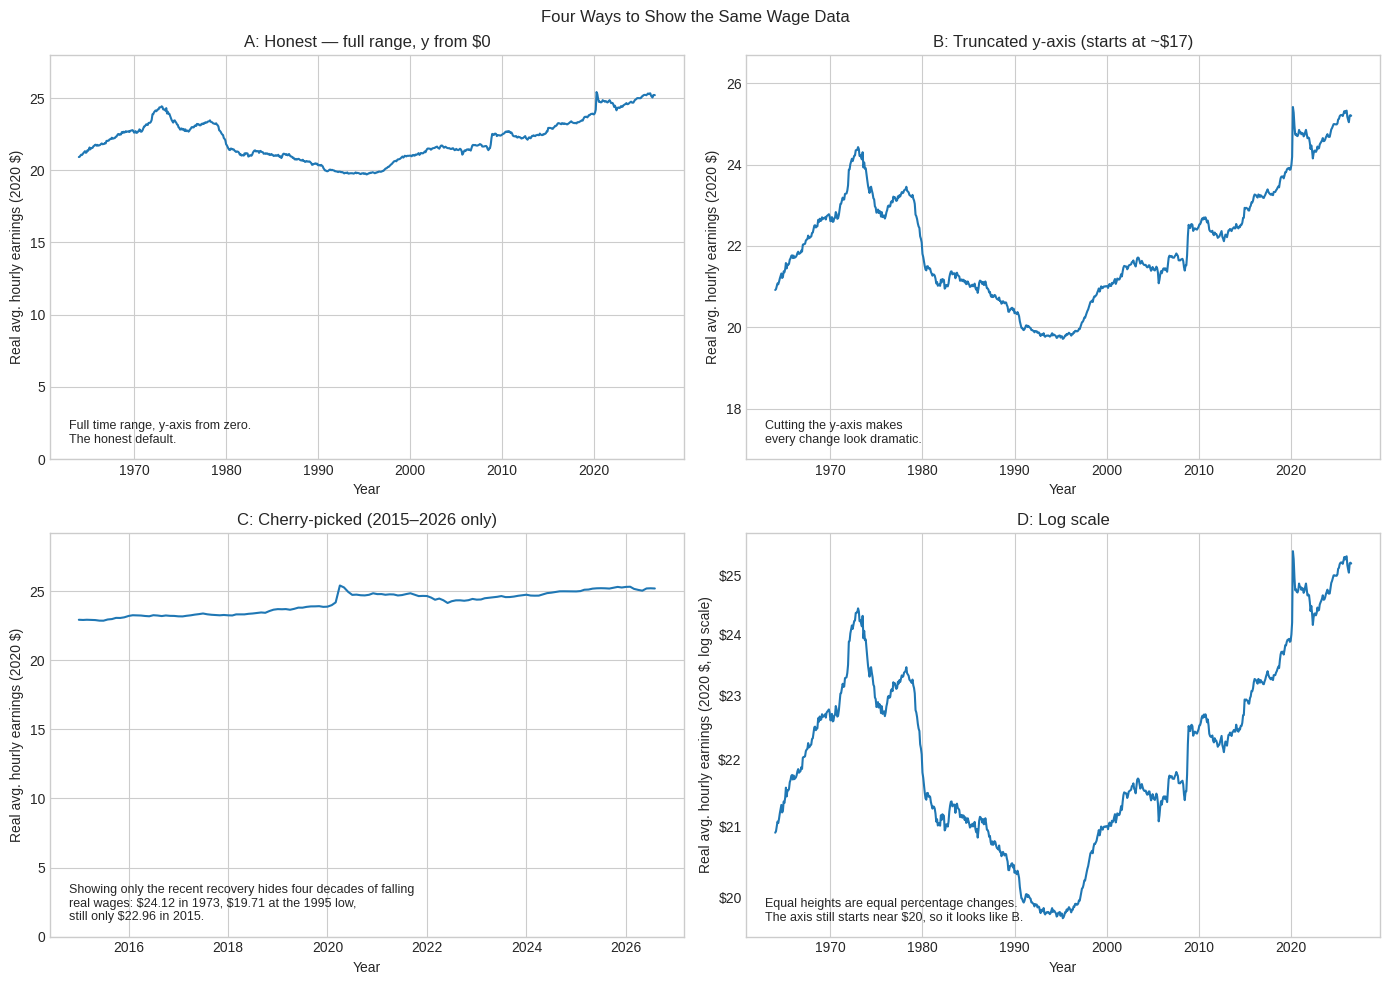

In [26]:
# GUIDED — run as-is
# Step 7: four panels, four stories, one dataset

def wage_panel(ax, data, title, note):
    """Draw real wages on one panel, with a title, axis labels and a note."""
    ax.plot(data.index, data["wage"])
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Real avg. hourly earnings (2020 $)")
    # transform=ax.transAxes places the note by fraction of the panel, not by data value;
    # parse_math=False prints $ as a dollar sign (two $ would otherwise start a formula)
    ax.text(0.03, 0.04, note, transform=ax.transAxes, fontsize=9, parse_math=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

wage_panel(axes[0, 0], wages, "A: Honest — full range, y from $0",
           "Full time range, y-axis from zero.\nThe honest default.")
axes[0, 0].set_ylim(0, wages["wage"].max() * 1.1)

cut = wages["wage"].min() * 0.85
wage_panel(axes[0, 1], wages, f"B: Truncated y-axis (starts at ~${cut:.0f})",
           "Cutting the y-axis makes\nevery change look dramatic.")
axes[0, 1].set_ylim(cut, wages["wage"].max() * 1.05)

recent = wages.loc["2015":]
wage_panel(axes[1, 0], recent,
           f"C: Cherry-picked ({recent.index[0].year}–{recent.index[-1].year} only)",
           f"Showing only the recent recovery hides four decades of falling\n"
           f"real wages: ${avg_1973:.2f} in 1973, ${trough:.2f} at the {trough_date.year} low,\n"
           f"still only ${avg_2015:.2f} in 2015.")
axes[1, 0].set_ylim(0, recent["wage"].max() * 1.15)

wage_panel(axes[1, 1], wages, "D: Log scale",
           "Equal heights are equal percentage changes.\n"
           "The axis still starts near $20, so it looks like B.")
axes[1, 1].set_yscale("log")
axes[1, 1].set_ylabel("Real avg. hourly earnings (2020 $, log scale)")
axes[1, 1].yaxis.set_minor_formatter("${x:.0f}")      # label the log ticks in dollars

fig.suptitle("Four Ways to Show the Same Wage Data")
plt.tight_layout()
plt.show()

### Interpretation Questions

**Q1:** If you were a union negotiator trying to argue that workers deserve higher wages, which panel would you show management? Why?

**Q2:** If you were a Fed economist writing a policy report, which panel is the most appropriate? Why?

**Q3:** Panel D uses a log scale. For what types of economic data IS a log scale the honest choice? Give two examples.

*Your answers here:*

1. In my opinion, panel A (the honest data), actually displays the most concerning/applicable reasoning behind real wage increases in this scenario. I B&D both magnify the rate of change, making recent raises seem larger, but as we go back to A, we can see those rates of change are much more horizontal, and our recent peak in ~2018 is only equivalent to that of ~1970.
2. I would also find panel A to be most appropriate as it minimizes the lie factor, allowing readers to interpret changes in the visualization at an equivalent level to that of the data.
3. Log scales can be ideal for compounding rates of change in data and/or exponential rates of change in data. If the time horizion is long enough, any linear visualziation of exponential/compounding rates of change cause later datapoints to significantly distort visual representations. One example could be stock price, or GDP of a country over time.

## Part 4: Systematic EDA on World Bank Data (GUIDED — 15 min)

A complete EDA follows a checklist: **Structure → Distributions → Relationships → Anomalies.** We walk through each step using World Bank GDP data.

The file has four columns: `Country Name`, `Country Code`, `Year`, and `Value`,
which is GDP in current US dollars.

In [27]:
# GUIDED — run as-is
# Step 8: load the World Bank GDP file, then EDA step 1: structure

url_wb = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"
gdp = pd.read_csv(url_wb)

print(f"Shape: {gdp.shape[0]} rows x {gdp.shape[1]} columns")
print(f"\nData types:\n{gdp.dtypes}")
print(f"\nUnique values per column:\n{gdp.nunique()}")
print(f"\nYear range: {gdp['Year'].min()} to {gdp['Year'].max()}")
print(f"Economies: {gdp['Country Code'].nunique()}")

# .isna() marks each missing value True; .sum() counts the Trues, .mean() gives their share
missing_values = gdp["Value"].isna()
print(f"Missing GDP values: {missing_values.sum()} ({missing_values.mean()*100:.1f}%)")

Shape: 13979 rows x 4 columns

Data types:
Country Name     object
Country Code     object
Year              int64
Value           float64
dtype: object

Unique values per column:
Country Name      262
Country Code      262
Year               64
Value           13900
dtype: int64

Year range: 1960 to 2023
Economies: 262
Missing GDP values: 0 (0.0%)


**Expected output:** 13,979 rows x 4 columns, 262 economies, 1960 to 2023: a
panel of many countries over many years. Not all 262 are countries. World, Euro
area, High income and other aggregates are rows here too, so an average across
all of them counts much of the planet twice. Missing GDP values: 0. Step 11 shows
why that zero is misleading.

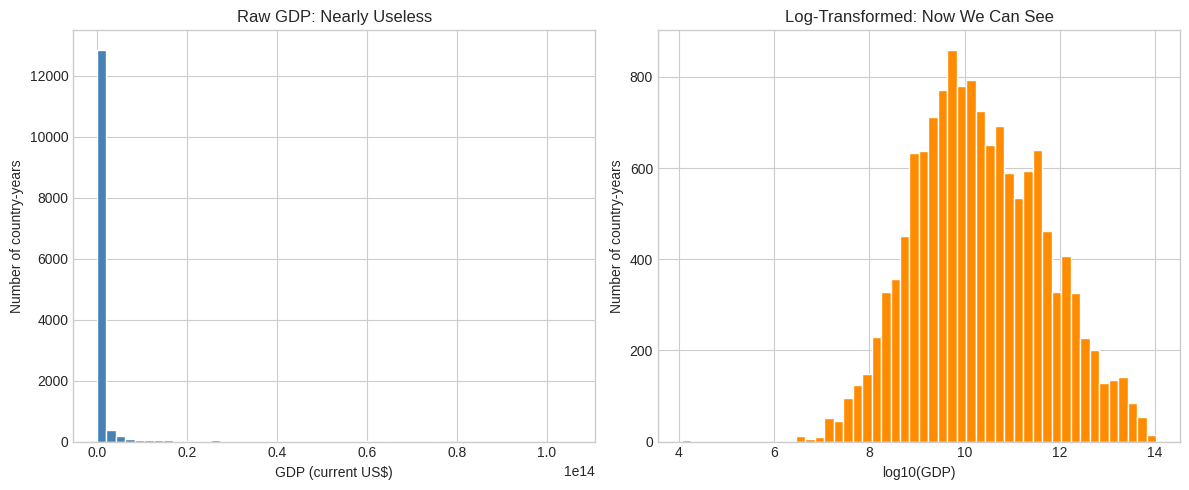

Skewness of raw GDP: 8.4
Skewness of log GDP: 0.2


In [28]:
# GUIDED — run as-is
# Step 9: EDA step 2: distributions. Raw GDP, then log GDP

log_gdp = np.log10(gdp["Value"])      # log10 turns 1e9 into 9 and 1e12 into 12

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(gdp["Value"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("GDP (current US$)")
axes[0].set_ylabel("Number of country-years")
axes[0].set_title("Raw GDP: Nearly Useless")

axes[1].hist(log_gdp, bins=50, color="darkorange", edgecolor="white")
axes[1].set_xlabel("log10(GDP)")
axes[1].set_ylabel("Number of country-years")
axes[1].set_title("Log-Transformed: Now We Can See")

plt.tight_layout()
plt.show()

print(f"Skewness of raw GDP: {gdp['Value'].skew():.1f}")
print(f"Skewness of log GDP: {log_gdp.skew():.1f}")

Step 10 is the chart shape Problem Set 1 asks for: several lines on one axes,
both axes labelled with units, a legend saying which line is which, and a title
that states what the reader should see rather than naming the variables.

Current dollars are fine for comparing countries in the same year; the rise
over time is partly inflation (Lab 2's rule).

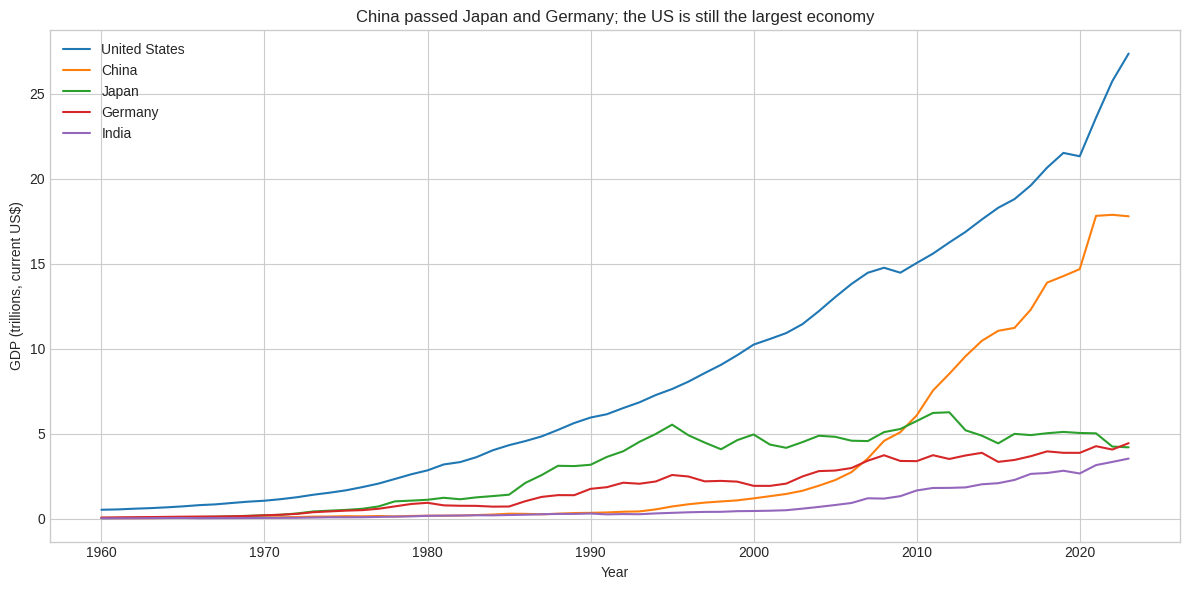

In [29]:
# GUIDED — run as-is
# Step 10: EDA step 3: relationships over time. GDP of five economies

fig, ax = plt.subplots(figsize=(12, 6))

for code in ["USA", "CHN", "JPN", "DEU", "IND"]:
    one = gdp[gdp["Country Code"] == code].sort_values("Year")
    name = one["Country Name"].iloc[0]                         # "United States", not "USA"
    ax.plot(one["Year"], one["Value"] / 1e12, label=name)     # 1e12 is one trillion

ax.set_xlabel("Year")
ax.set_ylabel("GDP (trillions, current US$)")
ax.set_title("China passed Japan and Germany; the US is still the largest economy")
ax.legend()
plt.tight_layout()
plt.show()

Careful before Step 11: the NaN count in Step 8 is 0 by construction. The World
Bank file stores a gap as an **absent row**, not as a NaN. The gaps only become
visible once you pivot the data to one row per country and one column per year,
which is what the heatmap below does.

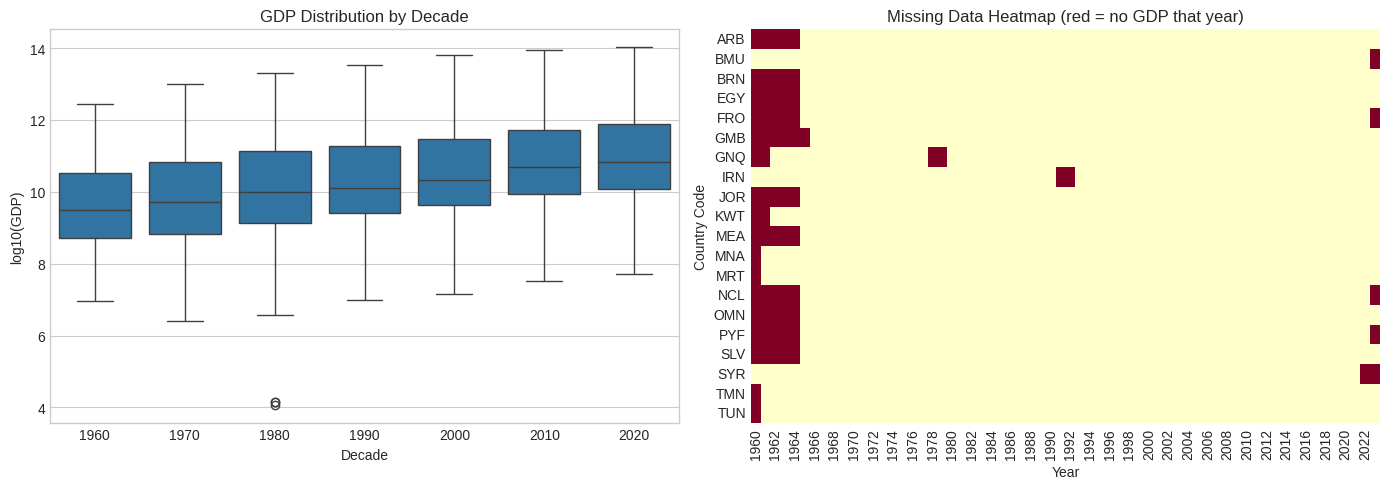

NaN cells in the long format:     0
Gaps visible in the pivoted panel: 74 of 1280 country-years
Negative GDP values (impossible): 0


In [30]:
# GUIDED — run as-is
# Step 11: EDA step 4: anomalies. GDP by decade, and a map of missing country-years

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# // divides and drops the remainder, so 1987 // 10 * 10 is 1980
decade = gdp["Year"] // 10 * 10
sns.boxplot(x=decade, y=np.log10(gdp["Value"]), ax=axes[0])
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("log10(GDP)")
axes[0].set_title("GDP Distribution by Decade")

# Take 20 economies with PARTIAL coverage: the 20 most complete would give a solid map
counts = gdp["Country Code"].value_counts()
partial = counts[counts < counts.max()].head(20).index
panel = gdp[gdp["Country Code"].isin(partial)].pivot_table(
    index="Country Code", columns="Year", values="Value", aggfunc="first")
missing = panel.isna()

sns.heatmap(missing.astype(int), ax=axes[1], cmap="YlOrRd", cbar=False)
axes[1].set_title("Missing Data Heatmap (red = no GDP that year)")

plt.tight_layout()
plt.show()

print(f"NaN cells in the long format:     {gdp['Value'].isna().sum()}")
print(f"Gaps visible in the pivoted panel: {missing.values.sum()} of {missing.size} country-years")
print(f"Negative GDP values (impossible): {(gdp['Value'] < 0).sum()}")

### EDA Checklist Summary

| Step | Question | Tool | What We Found |
|------|----------|------|---------------|
| **Structure** | What shape is the data? Panel/cross-section/time series? | `.shape`, `.dtypes`, `.nunique()` | Panel: many countries x many years |
| **Distributions** | Is the data skewed? Are there impossible values? | Histograms, `.skew()` | Extremely right-skewed; log transform needed |
| **Relationships** | What patterns exist between variables or over time? | Line plots | China's rapid rise; US still largest |
| **Anomalies** | Missing data? Outliers? Impossible values? | Box plots, missing heatmap | Coverage is thin early and thin again at the very end: ~85% of these countries are missing in 1960 and ~25% in 2023, and only six country-years in between |

### Interpretation Questions

**Q1:** Why is the raw GDP histogram nearly useless? What transformation fixes it, and why does it work?

**Q2:** Look at the missing data heatmap. Almost all the gaps sit at the two ends of the period, not scattered through it. Is that missingness MCAR (completely at random), MAR (at random conditional on observed data), or MNAR (not at random)? Explain your reasoning.

*Your answers here:*

1. Our data has a heavy right skew, a few countries account (Ex: Us, China) for the vast majority of total global GDP. Using a raw histogram then forces 100+ countries (maybe 200+) into the FIRST bin of the histogram, giving us largely unreadable/indistinguisable visualziations. This can be fixed by utilizing a log scale, which equalizes the ratio between bin sizes rather than by their absolute value (a +1 on this logscale displays 10X increase visually).This allows for far greater differentiation in what was previously our overfilled bin 1 of the regular histogram.
2. I would classify this missing data as MNAR, as it its clustering at the beginning and end of our timeline indicate that certain countries may not have been included at the start of this data's tracking. Data missing towards the end of the timeline may have a few reasons, one of which being countries having their GDP recorded late/delayed for some reason (those coutnries with only one blip at the end), however syria may have been due to its extreme economic instability due to political instability and conflict.

### Before the expansion: save the data

The toggler you are about to build runs on `wages`, and anything you open
outside this notebook — another Colab, a script, a chat assistant — cannot see
it. The cell below writes the three datasets to disk and zips them.

One more reason here: **FRED revises**. These files pin the exact series you
worked with today, so your chart and your README keep agreeing with each other
next week.

To reload the wage data anywhere, and to see the two columns the toggler needs:

```python
wages = pd.read_csv("wages.csv", index_col=0, parse_dates=True)
wages["AHETPI"]   # nominal
wages["wage"]     # real, 2020 dollars
```

In [31]:
# GUIDED — run as-is
# Save the three datasets and zip them, so your chart can run outside this notebook
import zipfile

wages.to_csv("wages.csv")                        # keeps the date index; columns AHETPI, CPIAUCSL, wage
anscombe.to_csv("anscombe.csv", index=False)     # index=False: no stray "Unnamed: 0" column
gdp.to_csv("worldbank_gdp.csv", index=False)
print(f"wrote wages.csv {wages.shape}")
print(f"wrote anscombe.csv {anscombe.shape}")
print(f"wrote worldbank_gdp.csv {gdp.shape}")

bundle = "lab3_chart_bundle.zip"
# "with" opens the zip file and closes it when the indented block ends
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as z:
    for name in ["wages.csv", "anscombe.csv", "worldbank_gdp.csv"]:
        z.write(name)
print(f"Zipped to {bundle}")

# In Colab this downloads the zip; elsewhere there is no google.colab, and the zip stays here
try:
    from google.colab import files
    files.download(bundle)
except ModuleNotFoundError:
    pass

wrote wages.csv (751, 3)
wrote anscombe.csv (44, 3)
wrote worldbank_gdp.csv (13979, 4)
Zipped to lab3_chart_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## AI-Assisted Expansion: Honest-Chart Toggler

**AI policy: foundations first, expansion second.** You have worked through Anscombe's Quartet, the Lie Factor, four framings of one wage series and an EDA checklist by hand. From here on, AI may write code for you (the Co-Pilot Rule).

### Your Expansion Task
Build an interactive chart (ipywidgets + matplotlib, running inside Colab) of the FRED wage data that lets the user:
1. Switch between nominal and real (2020 $) hourly earnings
2. Drag the y-axis floor up from $0 and watch the Lie Factor readout climb
3. Pick the start and end year of the window
4. Toggle between a linear and a log y-axis

Every setting should print the Lie Factor for the change from the first to the last year shown.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ---------------------------------------------------------------- data
# Fresh-notebook safe: load straight from the uploaded file.
wages = pd.read_csv("wages.csv", index_col=0, parse_dates=True).sort_index()
YEARS = wages.index.year                      # slice on the index, no year column
Y_MIN, Y_MAX = int(YEARS.min()), int(YEARS.max())

SERIES = {"AHETPI": "Nominal earnings ($ of the day)",
          "wage":   "Real earnings (2020 dollars)"}


# --------------------------------------------------------- Lie Factor
def lie_factor(first, last, bottom, log=False):
    """Tufte's Lie Factor = (size of effect shown in graphic) / (size of effect in data).

    Effect in data    = (last - first) / first          (relative change)
    Effect in graphic = (bar/line height at end - height at start) / height at start,
    where "height" is measured from the bottom of the drawn axis:
        linear axis: height = value - bottom
        log axis:    height = log(value / bottom)

    Linear algebra: shown = (last - first) / (first - bottom), so
        LF = first / (first - bottom).
    With bottom = 0 (linear) that is first / first = 1.0 -- the graphic is
    proportional to the data. Any bottom > 0 shrinks the denominator, so the
    same absolute change looks like a much larger *relative* change: LF > 1.
    """
    data_effect = (last - first) / first
    if log:
        h_first, h_last = np.log(first / bottom), np.log(last / bottom)
    else:
        h_first, h_last = first - bottom, last - bottom
    shown_effect = (h_last - h_first) / h_first
    return np.nan if data_effect == 0 else shown_effect / data_effect


# Mechanism check: the readout must be exactly 1.0 when the floor is $0.
assert np.isclose(lie_factor(5.0, 25.0, 0.0), 1.0), "Lie Factor should be 1.0 at a $0 floor"


# ------------------------------------------------------------- render
def render(series, floor, start, end, scale):
    if start >= end:
        print("Pick a start year earlier than the end year.")
        return
    window = wages.loc[(YEARS >= start) & (YEARS <= end), series].dropna()
    if len(window) < 2:
        print("Not enough observations in this window.")
        return

    log = scale == "log"
    first, last = window.iloc[0], window.iloc[-1]   # first / last observation shown
    lo, hi = window.min(), window.max()

    # The axis bottom must sit below the data or the line leaves the chart.
    bottom = min(floor, 0.95 * lo)
    clamped = floor > bottom
    if log and bottom <= 0:
        bottom = 0.5 * lo          # log axes cannot reach $0; pick a visible bottom
    top = hi * 1.05

    lf = lie_factor(first, last, bottom, log=log)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(window.index, window.values, lw=2, color="tab:blue")
    ax.scatter([window.index[0], window.index[-1]], [first, last],
               color="tab:red", zorder=3)
    ax.set_yscale("log" if log else "linear")
    ax.set_ylim(bottom, top)
    ax.set_ylabel("Dollars per hour")
    ax.set_title(f"{SERIES[series]}, {start}-{end}")
    ax.grid(alpha=0.3)
    plt.show()
    plt.close(fig)

    pct = (last - first) / first * 100
    verdict = ("roughly honest (0.95-1.05)" if 0.95 <= lf <= 1.05
               else "EXAGGERATES the change" if lf > 1.05 else "UNDERSTATES the change")
    print(f"Change in the data : ${first:.2f} -> ${last:.2f}  ({pct:+.1f}%)")
    # Effect shown = LF * effect in data, i.e. how big the change *looks*
    # relative to the starting height. This is the number that moves when you
    # change the axis scale or floor; the data change above never does.
    print(f"Change shown       : {lf * pct:+.1f}% (apparent growth in line height)")
    print(f"Axis bottom drawn  : ${bottom:.2f} ({scale})")
    print(f"Lie Factor         : {lf:.2f}  -> {verdict}")
    if clamped:
        print("(Floor clamped to just under the lowest value in the window.)")
    if log:
        print("(Log axis: $0 is impossible, so LF is measured against the drawn "
              "bottom. Equal ratios get equal height, so LF is not 1.0 here.)")


# ----------------------------------------------------------- widgets
series_w = widgets.ToggleButtons(options=[("Nominal", "AHETPI"), ("Real 2020 $", "wage")],
                                 description="Series:")
scale_w = widgets.ToggleButtons(options=["linear", "log"], description="Y-axis:")
floor_w = widgets.FloatSlider(value=0, min=0, max=float(np.ceil(wages[["AHETPI", "wage"]].max().max())),
                              step=0.5, description="Y floor $:", continuous_update=False,
                              layout=widgets.Layout(width="500px"))
start_w = widgets.IntSlider(value=Y_MIN, min=Y_MIN, max=Y_MAX, description="Start:",
                            continuous_update=False, layout=widgets.Layout(width="500px"))
end_w = widgets.IntSlider(value=Y_MAX, min=Y_MIN, max=Y_MAX, description="End:",
                          continuous_update=False, layout=widgets.Layout(width="500px"))

out = widgets.interactive_output(render, {"series": series_w, "floor": floor_w,
                                          "start": start_w, "end": end_w, "scale": scale_w})
display(widgets.VBox([series_w, scale_w, floor_w, start_w, end_w, out]))

# ------------------------------------------------- why nominal != real
# Nominal AHETPI is measured in the dollars of each year, so it mixes real
# growth with inflation: it rises steadily almost regardless of how workers
# are doing. Real "wage" divides by CPI (CPIAUCSL) to restate every year in
# 2020 dollars, leaving only changes in purchasing power; it is flatter and
# can even fall. For comparing decades, the REAL series is the honest one,
# because a 1970 dollar and a 2020 dollar are not the same unit.

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. On first ask, the change in data did not update as the slider moved, it only showed the start/end datapoints. I asked (Claude), to update this with the slider, and it successfully did so (as well as added an extra "Change Shown:" output that mirrored the change in data output.
2. As no actual statistical outptus themselves were wrong, I only had to verify across different settings and slider levels that the change in data never actually updated.
3. Most importantly for future work, I would've asked it to show me the changes in code, as it simply instantly updated the code it had previously given me, writing over the previous lines, and I was unable to compare the differences side-by-side. For this use-case I really can't think of much else I would change, other than perhaps changing the explanation output to be a bit more professional, and potentially to "bullet point it" so that it reads less like a mild string of thought.

## Part 5: Write your README

Your README is what a reader sees before they open a single cell. Draft it with
the README prompt in the Digital Portfolio section below, then check every
number in the draft against your own output.

---
## Digital Portfolio: your README prompt

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

```
I need help writing a project README for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Recreated Anscombe's Quartet: four datasets with the same means,
  variances and correlation but completely different shapes
* Computed a Lie Factor of [YOUR VALUE] for a truncated-axis revenue chart
  and redesigned it honestly
* Drew four versions of real average hourly earnings (FRED AHETPI,
  deflated to 2020 dollars) that told four different stories
* Ran a four-step EDA checklist (structure, distributions, relationships,
  anomalies) on World Bank GDP data: [YOUR VALUE] economies (countries plus
  aggregates such as World), [YOUR VALUE] years
* Built an interactive honest-chart toggler with a live Lie Factor

**Please write a README.md entry including:**
1. Project Title: Honest vs. Misleading Visualizations
2. Objective: one sentence
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Write it plainly, in the first person. No words like 'robust', 'comprehensive'
or 'leverage'. Use only the numbers I gave you.
```

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab03-visualization`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab03-visualization`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab03-visualization`, branch `main`,
   commit message `Lab 03 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**End of Lab 3.** You measured how far a truncated axis exaggerates (the Lie
Factor), saw why summary statistics alone are never enough (Anscombe), and ran
a four-step EDA before drawing any conclusions. Every chart is a rhetorical
choice: make yours honest.